# Single-Graph Evaluation + t-SNE

Notebook này dùng để **evaluate mô hình single-graph hiện tại** và vẽ **t-SNE của graph embeddings**.

Nó đã bỏ các phần dư thừa của notebook cũ và giữ lại những phần cần thiết nhất:

1. Load checkpoint + test graphs  
2. Evaluate trên test set  
3. Classification report + confusion matrix  
4. t-SNE trên graph embeddings  
5. Bảng misclassified cases (gọn)

> Lưu ý: notebook này giả định checkpoint thuộc mô hình `GraphAttentionKAN` hiện tại và file local `../networks/graph_attention_kan.py` là đúng bản bạn đã dùng để train.


In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.append('../')
print(sys.path[-3:])

['', '/home/hieutt/miniconda3/envs/torchtf/lib/python3.9/site-packages', '../']


In [7]:
import os
import json
import math
import random
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
)
from sklearn.manifold import TSNE

import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

from networks.graph_attention_ffn_kan import GraphAttentionKAN

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
sns.set_context("notebook")

In [3]:
# ========= CONFIG =========
PROJECT_ROOT = Path("..").resolve()

GRAPH_FOLDER = PROJECT_ROOT / "data/2017-subaru-forester/graphs_v1_small"
CKPT_PATH = PROJECT_ROOT / "save/graph_attention_ffn_kan/graph_attention_ffn_kan_best_test_macro_f1.pth"

SPLIT = "test"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

BATCH_SIZE = 128
NUM_WORKERS = 4
MAX_SHARDS = 0      # 0 = load all shards
MAX_SAMPLES = 0     # 0 = use all graphs in split

TSNE_MAX_POINTS = 3000   # downsample for faster t-SNE if needed
TSNE_PERPLEXITY = 30
TSNE_RANDOM_STATE = 42

print("GRAPH_FOLDER:", GRAPH_FOLDER)
print("CKPT_PATH   :", CKPT_PATH)
print("DEVICE      :", DEVICE)
print("graph exists:", GRAPH_FOLDER.exists())
print("ckpt exists :", CKPT_PATH.exists())

GRAPH_FOLDER: /home/hieutt/CAN-SupCon-IDS/data/2017-subaru-forester/graphs_v1_small
CKPT_PATH   : /home/hieutt/CAN-SupCon-IDS/save/graph_attention_ffn_kan/graph_attention_ffn_kan_best_test_macro_f1.pth
DEVICE      : cuda
graph exists: True
ckpt exists : True


In [8]:
# ========= HELPERS =========
def load_table(base: Path) -> pd.DataFrame:
    pq = base.with_suffix(".parquet")
    csv = base.with_suffix(".csv")
    if pq.exists():
        return pd.read_parquet(pq)
    if csv.exists():
        return pd.read_csv(csv)
    raise FileNotFoundError(f"Cannot find {pq} or {csv}")


def infer_label_mapping(graph_folder: Path) -> Dict[int, str]:
    mapping = {}
    for split in ["train", "val", "test"]:
        try:
            df = load_table(graph_folder / f"graph_index_{split}")
            if "y" in df.columns and "window_label" in df.columns:
                pairs = df[["y", "window_label"]].drop_duplicates()
                for _, row in pairs.iterrows():
                    mapping[int(row["y"])] = str(row["window_label"])
        except Exception:
            continue
    if not mapping:
        raise RuntimeError("Could not infer label mapping from graph_index files.")
    return dict(sorted(mapping.items(), key=lambda kv: kv[0]))


def graph_dict_to_data(graph: dict, fallback_graph_id: Optional[str] = None) -> Data:
    data = Data(
        x=graph["x"].float(),
        edge_index=graph["edge_index"].long(),
        edge_attr=graph["edge_attr"].float(),
        edge_type=graph["edge_type"].long(),
        id_token=graph["id_index"].long(),
        y=graph["y"].view(-1).long(),
    )

    meta = graph.get("meta", {})
    data.attack_count = torch.tensor([int(meta.get("attack_count", 0))], dtype=torch.long)
    data.attack_ratio = torch.tensor([float(meta.get("attack_ratio", 0.0))], dtype=torch.float32)
    data.is_mixed_window = torch.tensor([int(bool(meta.get("is_mixed_window", False)))], dtype=torch.long)

    graph_id = graph.get("graph_id", fallback_graph_id if fallback_graph_id is not None else "unknown_graph")
    label_name = graph.get("window_label", None)
    data.graph_id = graph_id
    data.window_label = label_name if label_name is not None else None
    return data


def load_graph_split(
    graph_folder: Path,
    split_name: str,
    max_shards: int = 0,
    max_samples: int = 0,
) -> List[Data]:
    split_dir = graph_folder / split_name
    shard_paths = sorted(split_dir.glob(f"graphs_{split_name}_shard*.pt"))

    if len(shard_paths) == 0:
        raise FileNotFoundError(f"No shard files found in {split_dir}")

    if max_shards > 0:
        shard_paths = shard_paths[:max_shards]

    dataset: List[Data] = []
    count = 0
    for shard_path in shard_paths:
        shard_graphs = torch.load(shard_path, map_location="cpu", weights_only=False)
        for i, g in enumerate(shard_graphs):
            fallback_graph_id = f"{split_name}:{shard_path.stem}:{i}"
            dataset.append(graph_dict_to_data(g, fallback_graph_id=fallback_graph_id))
            count += 1
            if max_samples > 0 and count >= max_samples:
                return dataset
    return dataset


def build_model_from_ckpt(ckpt: dict, num_classes: int, num_ids: int, sample_data: Data, device: str = "cpu"):
    args = ckpt.get("args", {})

    model = GraphAttentionKAN(
        node_feat_dim=sample_data.x.size(1),
        edge_attr_dim=sample_data.edge_attr.size(1),
        num_classes=num_classes,
        num_ids=num_ids,
        hidden_dim=args.get("hidden_dim", 128),
        num_layers=args.get("num_layers", 3),
        heads=args.get("heads", 4),
        id_emb_dim=args.get("id_emb_dim", 32),
        rel_emb_dim=args.get("rel_emb_dim", 8),
        num_relations=args.get("num_relations", 4),
        dropout=args.get("dropout", 0.2),
        ffn_ratio=args.get("ffn_ratio", 2.0),

        # block KAN args (if present in current model)
        block_kan_grid_size=args.get("block_kan_grid_size", 5),
        block_kan_spline_order=args.get("block_kan_spline_order", 3),
        block_kan_scale_noise=args.get("block_kan_scale_noise", 0.1),
        block_kan_scale_base=args.get("block_kan_scale_base", 1.0),
        block_kan_scale_spline=args.get("block_kan_scale_spline", 1.0),

        # head KAN args
        kan_hidden=args.get("kan_hidden", 128),
        kan_grid_size=args.get("kan_grid_size", 5),
        kan_spline_order=args.get("kan_spline_order", 3),
        kan_scale_noise=args.get("kan_scale_noise", 0.1),
        kan_scale_base=args.get("kan_scale_base", 1.0),
        kan_scale_spline=args.get("kan_scale_spline", 1.0),
    ).to(device)

    missing, unexpected = model.load_state_dict(ckpt["model"], strict=False)
    print("Missing keys   :", missing[:10], "..." if len(missing) > 10 else "")
    print("Unexpected keys:", unexpected[:10], "..." if len(unexpected) > 10 else "")
    if len(missing) > 0 or len(unexpected) > 0:
        print("⚠️ Check your local model file if these are not expected.")
    model.eval()
    return model


@torch.no_grad()
def get_graph_embedding(model, data: Data, device: str = "cpu") -> torch.Tensor:
    model.eval()
    data = data.to(device)
    h = model.encode_nodes(data)
    batch = getattr(data, "batch", None)
    if batch is None:
        batch = torch.zeros(data.x.size(0), dtype=torch.long, device=data.x.device)
    g = model.readout(h, batch)
    return g


@torch.no_grad()
def evaluate_single_graph_model(model, loader, label_mapping: Dict[int, str], device: str = "cpu"):
    model.eval()

    y_true, y_pred = [], []
    probs_all = []
    logits_all = []
    embeddings_all = []
    graph_ids = []

    for batch in loader:
        batch = batch.to(device)
        logits, g = model(batch, return_graph_embedding=True)
        probs = F.softmax(logits, dim=1)
        pred = probs.argmax(dim=1)

        y_true.extend(batch.y.view(-1).detach().cpu().numpy().tolist())
        y_pred.extend(pred.detach().cpu().numpy().tolist())
        probs_all.append(probs.detach().cpu().numpy())
        logits_all.append(logits.detach().cpu().numpy())
        embeddings_all.append(g.detach().cpu().numpy())

        gid = getattr(batch, "graph_id", None)
        if gid is None:
            graph_ids.extend([f"graph_{len(graph_ids)+i}" for i in range(batch.y.numel())])
        elif isinstance(gid, list):
            graph_ids.extend(gid)
        else:
            # PyG sometimes collates strings into list automatically; fallback:
            try:
                graph_ids.extend(list(gid))
            except Exception:
                graph_ids.extend([str(gid)] * batch.y.numel())

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    probs = np.concatenate(probs_all, axis=0) if len(probs_all) else np.empty((0, len(label_mapping)))
    logits = np.concatenate(logits_all, axis=0) if len(logits_all) else np.empty((0, len(label_mapping)))
    embs = np.concatenate(embeddings_all, axis=0) if len(embeddings_all) else np.empty((0, 1))

    metrics = {
        "acc": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
        "balanced_acc": balanced_accuracy_score(y_true, y_pred),
    }

    return {
        "metrics": metrics,
        "y_true": y_true,
        "y_pred": y_pred,
        "probs": probs,
        "logits": logits,
        "embeddings": embs,
        "graph_ids": graph_ids,
    }


def report_dataframe(y_true, y_pred, label_mapping: Dict[int, str]) -> pd.DataFrame:
    labels = sorted(label_mapping.keys())
    target_names = [label_mapping[i] for i in labels]
    report = classification_report(
        y_true, y_pred,
        labels=labels,
        target_names=target_names,
        digits=4,
        zero_division=0,
        output_dict=True,
    )
    return pd.DataFrame(report).T


def plot_confusion_matrix(cm: np.ndarray, label_names: List[str], normalize: bool = True, figsize=(10, 8)):
    if normalize:
        denom = cm.sum(axis=1, keepdims=True).clip(min=1)
        cm_plot = cm / denom
        fmt = ".2f"
        title = "Normalized confusion matrix"
    else:
        cm_plot = cm
        fmt = "d"
        title = "Confusion matrix"

    plt.figure(figsize=figsize)
    sns.heatmap(cm_plot, annot=True, fmt=fmt, cmap="Blues",
                xticklabels=label_names, yticklabels=label_names)
    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.tight_layout()
    plt.show()


def run_tsne(embeddings: np.ndarray, max_points: int = 3000, perplexity: int = 30, random_state: int = 42):
    n = embeddings.shape[0]
    idx = np.arange(n)
    if n > max_points:
        rng = np.random.default_rng(random_state)
        idx = np.sort(rng.choice(n, size=max_points, replace=False))
        embeddings = embeddings[idx]

    tsne = TSNE(
        n_components=2,
        perplexity=min(perplexity, max(5, embeddings.shape[0] - 1)),
        init="pca",
        learning_rate="auto",
        random_state=random_state,
    )
    emb2d = tsne.fit_transform(embeddings)
    return emb2d, idx


def plot_tsne_embeddings(
    emb2d: np.ndarray,
    y_true: np.ndarray,
    y_pred: np.ndarray,
    label_mapping: Dict[int, str],
    title: str = "t-SNE of graph embeddings",
    figsize=(9, 7),
):
    plt.figure(figsize=figsize)

    labels = sorted(label_mapping.keys())
    cmap = plt.get_cmap("tab10" if len(labels) <= 10 else "tab20")

    for j, cls in enumerate(labels):
        mask = (y_true == cls)
        if mask.sum() == 0:
            continue
        plt.scatter(
            emb2d[mask, 0],
            emb2d[mask, 1],
            s=28,
            alpha=0.80,
            color=cmap(j % cmap.N),
            label=label_mapping[cls],
        )

    wrong = (y_true != y_pred)
    if wrong.sum() > 0:
        plt.scatter(
            emb2d[wrong, 0],
            emb2d[wrong, 1],
            s=75,
            facecolors="none",
            edgecolors="black",
            linewidths=1.1,
            label="misclassified",
        )

    plt.title(title)
    plt.xlabel("t-SNE dim 1")
    plt.ylabel("t-SNE dim 2")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
    plt.tight_layout()
    plt.show()


def misclassified_table(y_true, y_pred, probs, graph_ids, label_mapping: Dict[int, str], top_n: int = 20) -> pd.DataFrame:
    conf = probs.max(axis=1)
    rows = []
    for i in range(len(y_true)):
        if y_true[i] != y_pred[i]:
            rows.append({
                "graph_id": graph_ids[i] if i < len(graph_ids) else f"graph_{i}",
                "true_idx": int(y_true[i]),
                "pred_idx": int(y_pred[i]),
                "true_label": label_mapping[int(y_true[i])],
                "pred_label": label_mapping[int(y_pred[i])],
                "confidence": float(conf[i]),
            })
    if len(rows) == 0:
        return pd.DataFrame(columns=["graph_id","true_idx","pred_idx","true_label","pred_label","confidence"])
    return pd.DataFrame(rows).sort_values("confidence", ascending=False).head(top_n).reset_index(drop=True)

In [9]:
# ========= LOAD DATA =========
label_mapping = infer_label_mapping(GRAPH_FOLDER)
label_names = [label_mapping[i] for i in sorted(label_mapping)]

test_dataset = load_graph_split(
    GRAPH_FOLDER,
    split_name=SPLIT,
    max_shards=MAX_SHARDS,
    max_samples=MAX_SAMPLES,
)

print("Loaded test graphs:", len(test_dataset))
print("num_classes      :", len(label_mapping))
print("label_mapping    :", label_mapping)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE == "cuda"),
)

Loaded test graphs: 31538
num_classes      : 10
label_mapping    : {0: 'normal', 1: 'combined', 2: 'dos', 3: 'fuzzing', 4: 'gear', 5: 'interval', 6: 'rpm', 7: 'speed', 8: 'standstill', 9: 'systematic'}


In [10]:
# ========= LOAD CHECKPOINT + BUILD MODEL =========
ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
print("Checkpoint keys:", ckpt.keys())

num_classes = len(label_mapping)

# infer num_ids from test_dataset
num_ids = 0
for d in test_dataset:
    num_ids = max(num_ids, int(d.id_token.max().item()))
num_ids = int(num_ids) + 1

sample_data = test_dataset[0]
model = build_model_from_ckpt(
    ckpt=ckpt,
    num_classes=num_classes,
    num_ids=num_ids,
    sample_data=sample_data,
    device=DEVICE,
)

print("num_ids         :", num_ids)
print("sample x dim    :", sample_data.x.shape)
print("sample edge dim :", sample_data.edge_attr.shape)

Checkpoint keys: dict_keys(['epoch', 'model', 'optimizer', 'scheduler', 'scaler', 'best_val_macro_f1', 'best_val_acc', 'best_test_macro_f1', 'history', 'label_mapping', 'args'])
Missing keys   : [] 
Unexpected keys: [] 
num_ids         : 1568
sample x dim    : torch.Size([64, 16])
sample edge dim : torch.Size([332, 6])


## Run evaluation

In [11]:
outputs = evaluate_single_graph_model(
    model=model,
    loader=test_loader,
    label_mapping=label_mapping,
    device=DEVICE,
)

metrics = outputs["metrics"]
y_true = outputs["y_true"]
y_pred = outputs["y_pred"]
probs = outputs["probs"]
logits = outputs["logits"]
embeddings = outputs["embeddings"]
graph_ids = outputs["graph_ids"]

print("ACC         :", f"{metrics['acc']*100:.2f}%")
print("Macro-F1    :", f"{metrics['macro_f1']:.4f}")
print("Weighted-F1 :", f"{metrics['weighted_f1']:.4f}")
print("Balanced Acc:", f"{metrics['balanced_acc']:.4f}")
print("Embeddings  :", embeddings.shape)

ACC         : 99.75%
Macro-F1    : 0.9973
Weighted-F1 : 0.9975
Balanced Acc: 0.9973
Embeddings  : (31538, 256)


In [12]:
# Classification report
report_df = report_dataframe(y_true, y_pred, label_mapping)
display(report_df.round(4))

,precision,recall,f1-score,support
normal,0.9971,0.9973,0.9972,13957.0000
combined,0.9973,0.9964,0.9969,4457.0000
dos,1.0000,1.0000,1.0000,667.0000
fuzzing,0.9988,0.9988,0.9988,864.0000
gear,0.9902,1.0000,0.9951,704.0000
interval,0.9995,1.0000,0.9998,6363.0000
rpm,0.9985,0.9962,0.9974,1328.0000
speed,0.9925,0.9956,0.9940,1594.0000
standstill,1.0000,1.0000,1.0000,617.0000
systematic,0.9990,0.9889,0.9939,987.0000


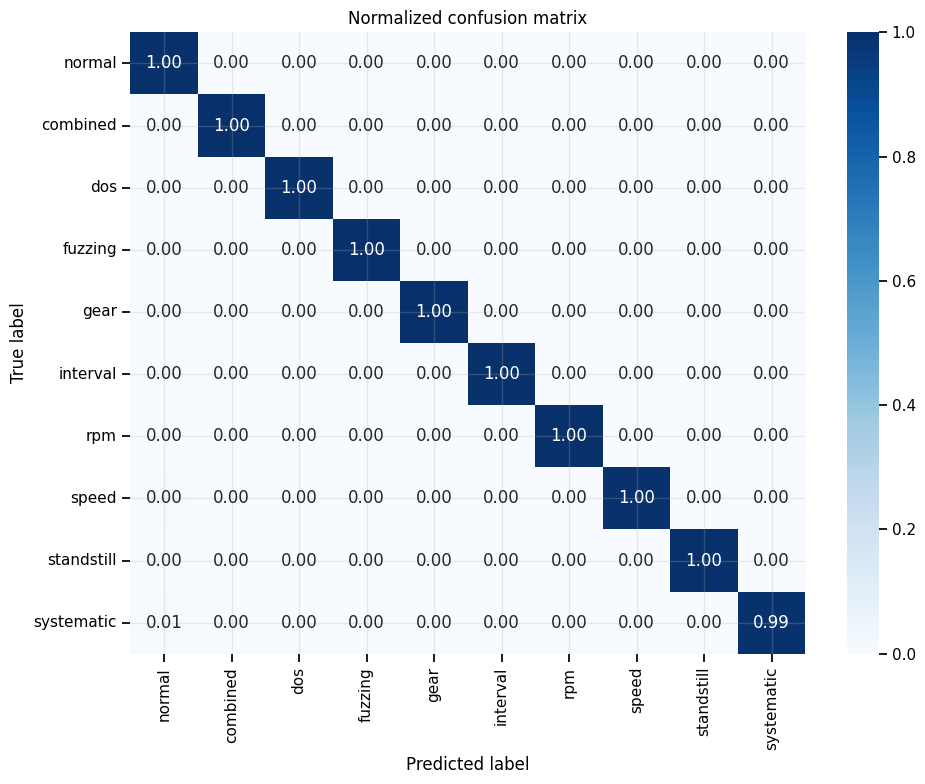

In [13]:
# Confusion matrix
labels = sorted(label_mapping.keys())
cm = confusion_matrix(y_true, y_pred, labels=labels)
plot_confusion_matrix(cm, label_names, normalize=True, figsize=(10, 8))

## t-SNE of graph embeddings

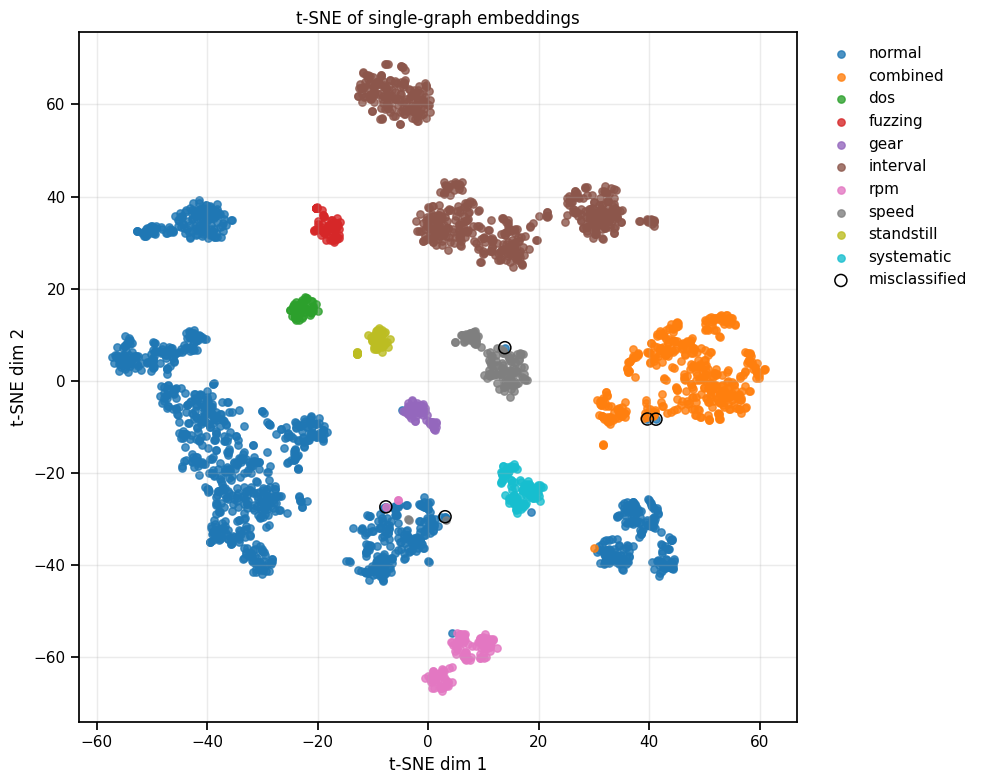

In [14]:
emb2d, kept_idx = run_tsne(
    embeddings,
    max_points=TSNE_MAX_POINTS,
    perplexity=TSNE_PERPLEXITY,
    random_state=TSNE_RANDOM_STATE,
)

y_true_tsne = y_true[kept_idx]
y_pred_tsne = y_pred[kept_idx]

plot_tsne_embeddings(
    emb2d=emb2d,
    y_true=y_true_tsne,
    y_pred=y_pred_tsne,
    label_mapping=label_mapping,
    title="t-SNE of single-graph embeddings",
    figsize=(10, 8),
)

## Optional: misclassified cases

In [15]:
mis_df = misclassified_table(
    y_true=y_true,
    y_pred=y_pred,
    probs=probs,
    graph_ids=graph_ids,
    label_mapping=label_mapping,
    top_n=20,
)
display(mis_df)

,graph_id,true_idx,pred_idx,true_label,pred_label,confidence
0,speed__03652928_03652992,7,0,speed,normal,1.000000
1,speed__00166336_00166400,7,0,speed,normal,1.000000
2,systematic__00363840_00363904,9,0,systematic,normal,1.000000
3,systematic__00364992_00365056,9,0,systematic,normal,1.000000
4,systematic__00317440_00317504,9,0,systematic,normal,1.000000
5,fuzzing__00799744_00799808,3,0,fuzzing,normal,1.000000
6,rpm__01643648_01643712,6,0,rpm,normal,1.000000
7,systematic__00452992_00453056,9,0,systematic,normal,1.000000
8,systematic__00328448_00328512,9,0,systematic,normal,1.000000
9,rpm__02047104_02047168,6,0,rpm,normal,1.000000


### Notes

- Nếu `Missing keys` / `Unexpected keys` xuất hiện khi load checkpoint, hãy kiểm tra lại file local `../networks/graph_attention_kan.py`.
- Notebook này ưu tiên **gọn**: không giữ các phần confidence histogram, attention analysis, hay các plot phụ khác.
- t-SNE được tính trên **graph embeddings sau readout**, nên nó phản ánh mức độ tách lớp của representation trước KAN head.
